In [1]:
#!git clone https://github.com/Rorschach1989/nfm.git

Cloning into 'nfm'...
remote: Enumerating objects: 694, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (240/240), done.
remote: Total 694 (delta 250), reused 232 (delta 139), pack-reused 313 (from 1)
Receiving objects: 100% (694/694), 3.58 MiB | 5.74 MiB/s, done.
Resolving deltas: 100% (471/471), done.


In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
from nfm.nfm.DatasetsDHS import SurvivalDataset
from nfm.nfm.base import MonotoneNLL
from nfm.nfm.eps_config import IGGEps
from nfm.nfm.metric import c_index
from nfm.nfm.utils import default_device
from pycox.evaluation.eval_surv import EvalSurv


data_full = SurvivalDataset.Zambia('./nfm/data/Zambia_cleanednew.csv')
fold_c_indices = []
fold_survival =  []
fold_ibs = []
fold_nbll = []
normalizing_factor = 366.25


def normalize(y):
    return (y + 1) / normalizing_factor


n_hidden = 128
n_hidden_umnn = 128


for i in tqdm(range(5)):
    torch.manual_seed(77+i)
    train_folds, valid_folds, test_folds = data_full.cv_split(shuffle=True)
    for i in range(5):
        test_c_indices, test_ibs, test_nbll = [], [], []
        valid_losses = []
        m = nn.Sequential(
            nn.Linear(in_features=621, out_features=n_hidden, bias=False),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=n_hidden, out_features=1, bias=False),
        ).to(default_device)
        nll = MonotoneNLL(eps_conf=IGGEps(),
                          num_hidden_units=n_hidden_umnn,
                          positive_transform='exp').to(default_device)
        optimizer = torch.optim.Adam(lr=1e-3, weight_decay=1e-2, params=list(m.parameters()) + list(nll.parameters()))
        loader = DataLoader(train_folds[i], batch_size=256)
        for epoch in range(30):
            for z, y, delta in loader:
                m.train()
                m_z = m(z)
                loss = nll(m_z=m_z, y=normalize(y), delta=delta)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            m.eval()
            with torch.no_grad():
                y_valid, delta_valid, z_valid = valid_folds[i].sort()
                y_test, delta_test, z_test = test_folds[i].sort()
                y_valid, y_test = normalize(y_valid), normalize(y_test)
                pred_valid = m(z_valid)
                pred_test = m(z_test)
                valid_loss = nll(pred_valid, y_valid, delta_valid)
                valid_losses.append(valid_loss)
                tg_test = np.linspace(y_test.cpu().numpy().min(), y_test.cpu().numpy().max(), 60)
                surv_pred_test = nll.get_survival_prediction(
                    pred_test, y_test=torch.tensor(tg_test, dtype=torch.float).view(-1, 1))
                test_evaluator = EvalSurv(
                    surv=pd.DataFrame(surv_pred_test.cpu().numpy(), index=tg_test.reshape(-1)),
                    durations=y_test.cpu().numpy().reshape(-1),
                    events=delta_test.cpu().numpy().reshape(-1),
                    censor_surv='km')
                test_c_indices.append(c_index(-pred_test, y_test, delta_test))
                test_ibs.append(test_evaluator.integrated_brier_score(time_grid=tg_test))
                test_nbll.append(test_evaluator.integrated_nbll(time_grid=tg_test))
        valid_argmin = np.argmin(valid_losses)
        fold_survival.append(np.asarray(surv_pred_test)[valid_argmin])
        fold_c_indices.append(np.asarray(test_c_indices)[valid_argmin])
        fold_ibs.append(np.asarray(test_ibs)[valid_argmin])
        fold_nbll.append(np.asarray(test_nbll)[valid_argmin])


report_str = f"""
Results:
    mean survival: {np.asarray(fold_survival).mean()}
    mean c-index: {np.asarray(fold_c_indices).mean()}
    std c-index: {np.asarray(fold_c_indices).std()}
    mean ibs: {np.asarray(fold_ibs).mean()}
    std ibs: {np.asarray(fold_ibs).std()}
    mean ibll: {np.asarray(fold_nbll).mean()}
    std ibll: {np.asarray(fold_nbll).std()}
"""
print(report_str)


/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                             | 0/5 [00:00<?, ?it/s]/home/justine/nfm/nfm/DatasetsDHS.py:313: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float, device=default_device).view(-1, 1)
/home/justine/nfm/nfm/DatasetsDHS.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.delta = torch.tensor(delta, dtype=torch.float, d


Results:
    mean survival: 0.9833887219429016
    mean c-index: 0.9159840941429138
    std c-index: 0.029585404321551323
    mean ibs: 0.02088817685140801
    std ibs: 0.0028270402721237496
    mean ibll: 0.0893130627568452
    std ibll: 0.011504105623808535



In [2]:
fold1=pd.DataFrame(fold_survival[1]).transpose()
fold1[1]

0    0.964327
Name: 1, dtype: float32

In [3]:
# Check the shape of each array in fold_survival
for i, fold in enumerate(fold_survival):
    print(f"Shape of fold {i+1}: {fold.shape}")



Shape of fold 1: (1346,)
Shape of fold 2: (1346,)
Shape of fold 3: (1346,)
Shape of fold 4: (1346,)
Shape of fold 5: (1346,)
Shape of fold 6: (1346,)
Shape of fold 7: (1346,)
Shape of fold 8: (1346,)
Shape of fold 9: (1346,)
Shape of fold 10: (1346,)
Shape of fold 11: (1346,)
Shape of fold 12: (1346,)
Shape of fold 13: (1346,)
Shape of fold 14: (1346,)
Shape of fold 15: (1346,)
Shape of fold 16: (1346,)
Shape of fold 17: (1346,)
Shape of fold 18: (1346,)
Shape of fold 19: (1346,)
Shape of fold 20: (1346,)
Shape of fold 21: (1346,)
Shape of fold 22: (1346,)
Shape of fold 23: (1346,)
Shape of fold 24: (1346,)
Shape of fold 25: (1346,)


In [4]:
df = pd.DataFrame(fold_survival).transpose()
df.to_csv("FULL_fold_survival_ZambiaNEW2", index=False)


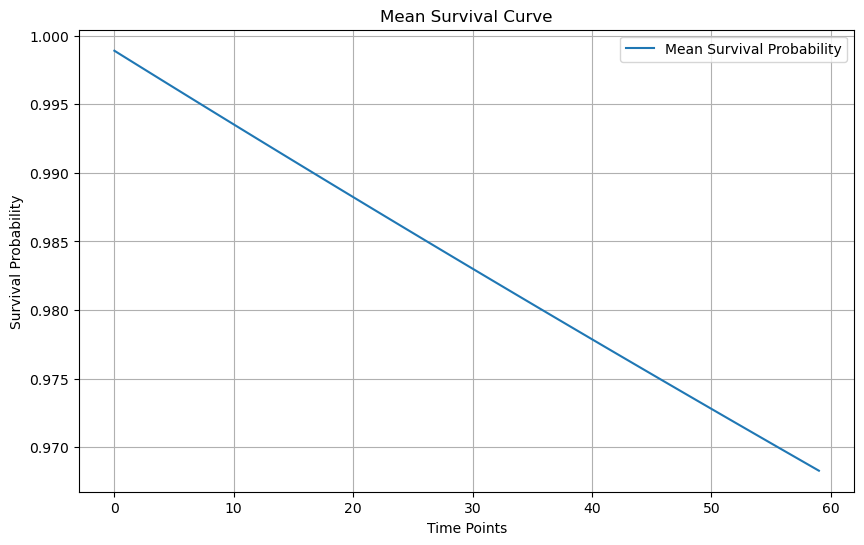

In [5]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
surv_pred_test_T_np

array([[0.9983198 , 0.99748284, 0.99664724, ..., 0.9529865 , 0.9522319 ,
        0.9514786 ],
       [0.99865514, 0.99798477, 0.9973153 , ..., 0.96202844, 0.96141326,
        0.9607989 ],
       [0.9989816 , 0.9984738 , 0.9979665 , ..., 0.9709931 , 0.97051877,
        0.970045  ],
       ...,
       [0.9989305 , 0.9983971 , 0.99786437, ..., 0.96957666, 0.96908   ,
        0.9685838 ],
       [0.9990554 , 0.99858415, 0.99811345, ..., 0.97303706, 0.9725953 ,
        0.9721539 ],
       [0.99853706, 0.997808  , 0.9970801 , ..., 0.958827  , 0.95816207,
        0.9574983 ]], dtype=float32)

In [7]:
df = pd.DataFrame(surv_pred_test_T_np)
df.to_csv('Zambia_resultssurvivalFULLNEW2.csv', index=False)

In [8]:
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsFULLdataZambiasresultsNEW2.csv', index=False)

In [9]:
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesFULLdataZambiasresultsNEW2.csv', index=False)


Text(0, 0.5, 'Values')

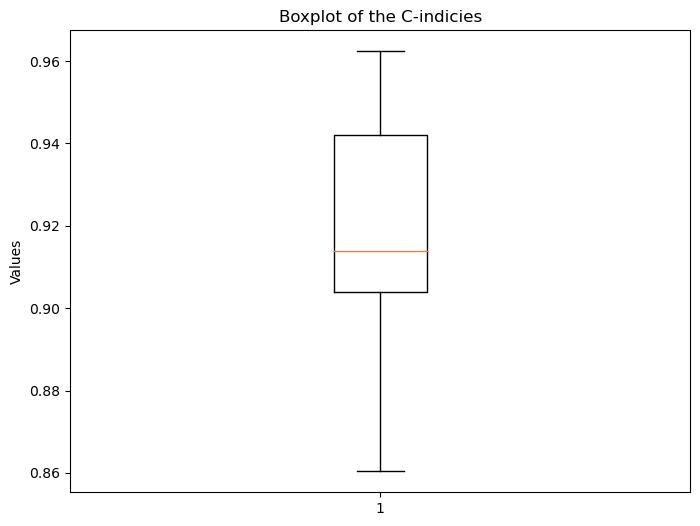

In [10]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

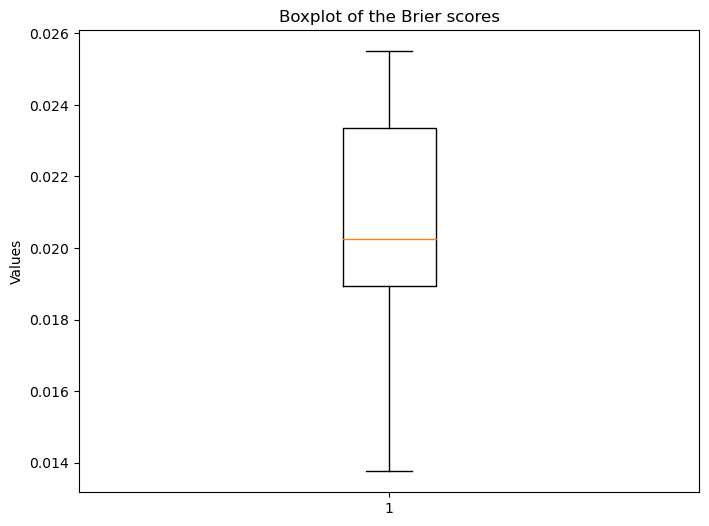

In [11]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')

No handles with labels found to put in legend.


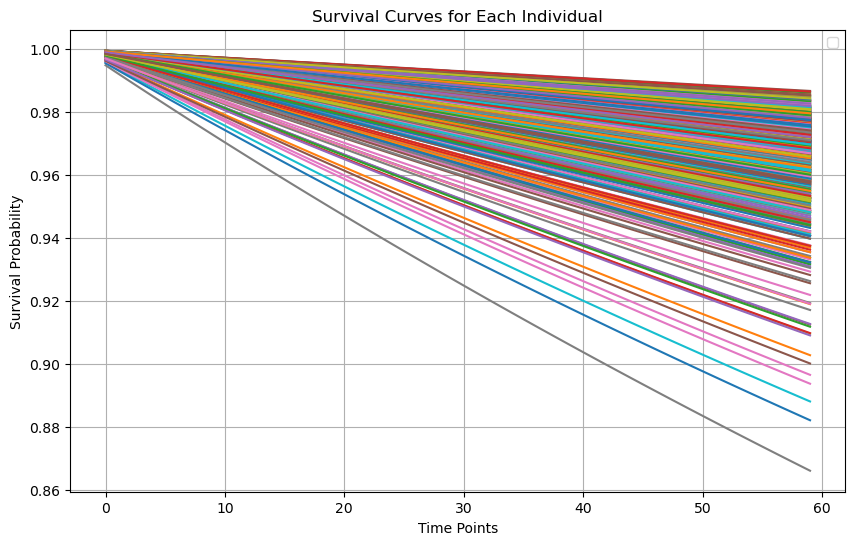

In [12]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

50

In [10]:
#train_folds
#valid_folds
#test_folds
#loader

No handles with labels found to put in legend.


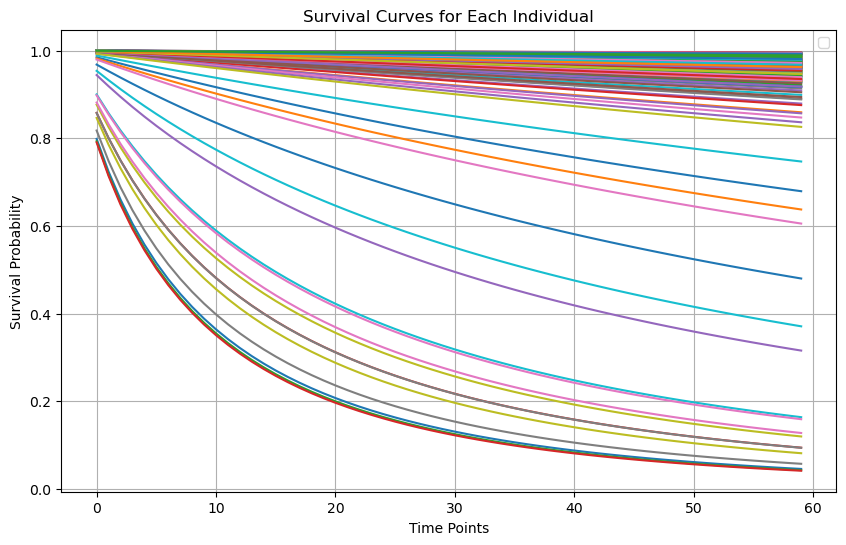

In [32]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

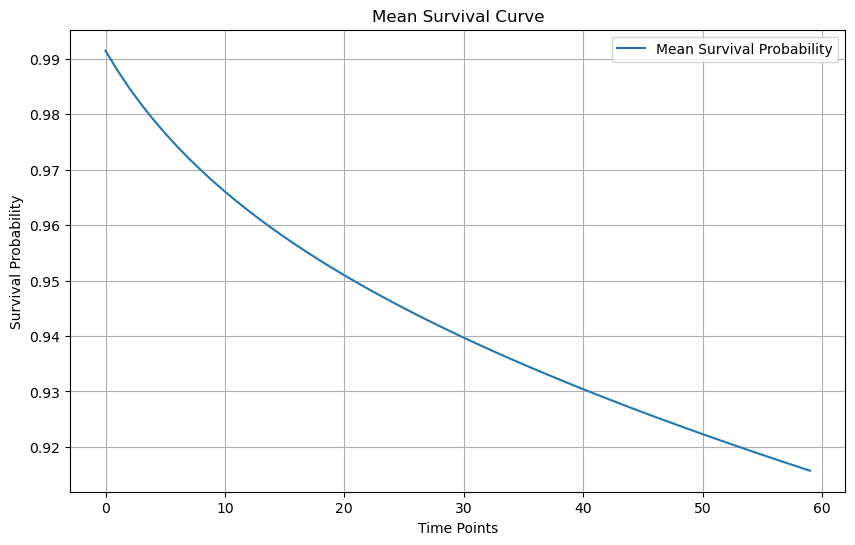

In [33]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Values')

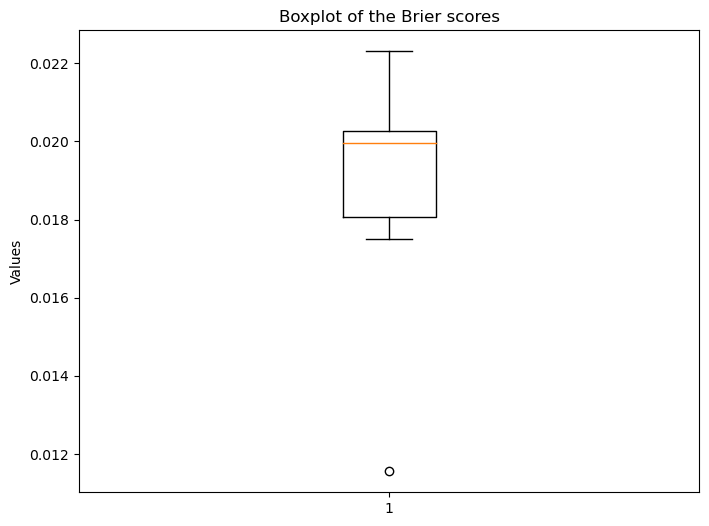

In [34]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

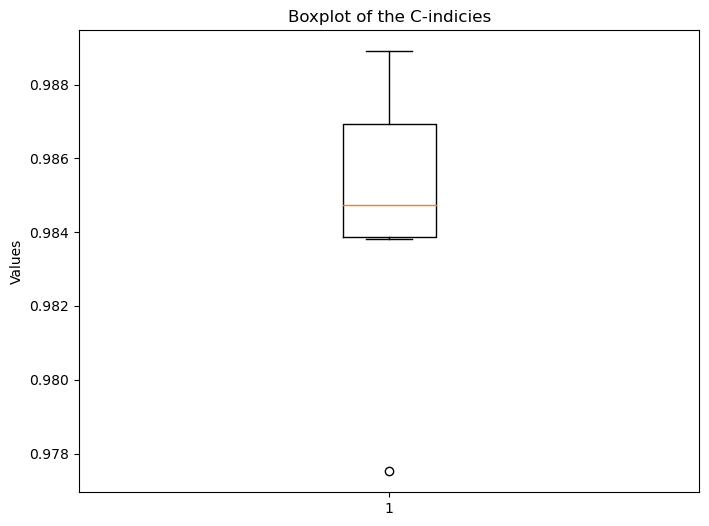

In [35]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')

In [26]:
#fold_c_indices.to_csv('Zambia_cleanednewcindexresults.csv', index=False)


In [31]:
#!pip install tqdm

In [1]:
import pandas as pd

df = pd.read_csv('./nfm/data/Zambia.csv')
print(df.columns)

Index(['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
       'Mother_education', 'husband_education', 'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M4_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode', 'V206_recode',
       'V209_recode', 'M18_recode', 'V151'],
      dtype='object')


In [2]:
df.shape[0]

9498

In [3]:
df

,CASEID,V001,MIDX,survival_time,Status,B4,Mother_education,husband_education,age_group,age_first_birth,...,M4_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V206_recode,V209_recode,M18_recode,V151
0,112,1,1,10.973306,0,Male,None,Complete Primary,30-39,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,1,Yes,4+,1,Yes,Large,Male
1,122,1,1,13.273101,0,Male,None,None,below 20,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,1,Yes,3,NaN,No,Average,Male
2,132,1,1,22.735113,0,Male,Complete Primary,Complete Primary,20-29,20-29,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,1,Yes,4+,NaN,No,Average,Male
3,132,1,2,43.564682,0,Female,Complete Primary,Complete Primary,20-29,20-29,...,"Ever breastfed, not currently breastfeeding",No,Biomass or Solid fuels,1,Yes,4+,NaN,No,Average,Male
4,142,1,1,4.271047,0,Male,None,Complete Primary,20-29,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,2,Yes,4+,NaN,Yes,Large,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,545242,545,1,7.523614,0,Female,Complete Primary,Complete Primary,below 20,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,1,Yes,3,NaN,Yes,Average,Male
9494,545262,545,1,28.188912,0,Male,Complete Primary,Complete Primary,20-29,20-29,...,"Ever breastfed, not currently breastfeeding",Yes,Biomass or Solid fuels,3,No,4+,NaN,No,Average,Male
9495,545262,545,2,28.188912,0,Female,Complete Primary,Complete Primary,20-29,20-29,...,"Ever breastfed, not currently breastfeeding",Yes,Biomass or Solid fuels,3,No,4+,NaN,No,Small,Male
9496,545292,545,1,18.858316,0,Female,Complete Primary,Complete Primary,20-29,below 20,...,Still breastfeeding,No,Biomass or Solid fuels,2,Yes,4+,NaN,No,Average,Male


In [4]:
file_path = './nfm/data/Zambia.csv'


data_full = pd.read_csv(file_path)
features_to_remove = ['Mother_education', 'husband_education', 'V206_recode', 'M4_recode']
data_cleaned = data_full.drop(columns=features_to_remove)
Zambia =data_cleaned.dropna()

In [5]:
data_full.shape[0]

9498

In [6]:
Zambia.shape[0]

6730

In [7]:
Zambia.to_csv('Zambia_cleaned.csv', index=False)

In [9]:
import pandas as pd

# Load the Zambia dataset

file_path = 'nfm/data/Zambia_cleaned.csv'
Zambia_df = pd.read_csv(file_path)

# Predefined encoding maps


age_group_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30-39': 2, 
    '40+': 3
}

age_first_birth_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30+': 2
}

drinking_water_source_encoding = {
    'Piped water': 0, 
    'Borehole': 1, 
    'Well': 2, 
    'Surface/rain/pond/lake/tank': 3, 
    'Other': 4
}

Bord_recoded_encoding = { 
    '1': 1, 
    '2-3': 2, 
    '4-6': 3,
    '7+' : 4
}

V218_recoded_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V201_recoded_encoding = {
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V605_recode_encoding = {
    'No': 0, 
    'Yes': 1,
    'Undecided/Never had sex' : 3
}

V130_recode_encoding = { 
    'Christians': 1, 
    'Muslim': 2, 
    'Others': 3
}

M70_recode_encoding = {
    'No': 0, 
    'Yes': 1
}

V137_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

B4_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V404_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V213_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V405_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V502_recode_encoding = {
    'Never in union': 0, 
    'Currently in union/living with a man': 1,
    'Formerly in union/living with a man': 2
}

V190_recode_encoding = {
    'Poorest': 0, 
    'Poorer': 1, 
    'Middle': 2, 
    'Richer': 3, 
    'Richest': 4
}



M3A_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V161_recode_encoding = {
    'Others': 0, 
    'Energies': 1, 
    'Biomass or Solid fuels': 2, 
    'Kerosine': 3
}

V716_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V136_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}


V209_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

M18_recode_encoding = {
    'Small': 0, 
    'Average': 1,
    'Large' : 2
}

V151_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V208_recode_encoding = { 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

# Function to apply predefined encoding to columns
def apply_predefined_encoding(df, column, encoding_map, default_value=4):
    if column in df.columns:
        df[column] = df[column].map(encoding_map).fillna(default_value).astype(int)
    return df

# Apply encodings


Zambia_df = apply_predefined_encoding(Zambia_df, 'age_group', age_group_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'age_first_birth', age_first_birth_encoding, default_value=2)
Zambia_df = apply_predefined_encoding(Zambia_df, 'drinking_water_source', drinking_water_source_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'BORD_recoded', Bord_recoded_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V218_recoded', V218_recoded_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V201_recoded', V201_recoded_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V605_recode', V605_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V130_recode', V130_recode_encoding, default_value=3)
Zambia_df = apply_predefined_encoding(Zambia_df, 'M70_recode', M70_recode_encoding, default_value=2)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V404', V404_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'B4', B4_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V213', V213_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V405', V405_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V502', V502_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V190', V190_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'M3A', M3A_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V161_recode', V161_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V716_working', V716_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V136_recode', V136_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V209_recode', V209_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'M18_recode', M18_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V151', V151_recode_encoding)
Zambia_df = apply_predefined_encoding(Zambia_df, 'V208_recoded', V208_recode_encoding)

# Update column names
Zambia_df.columns = ['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
         'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

# Display the preprocessed dataset
Zambia_df.head()


,CASEID,V001,MIDX,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,112,1,1,10.973306,0,1,2,0,1,4,...,1,0,0,2,1,1,4,1,2,1
1,122,1,1,13.273101,0,1,0,0,1,1,...,1,1,0,2,1,1,3,0,1,1
2,132,1,1,22.735113,0,1,1,1,1,2,...,1,0,0,2,1,1,4,0,1,1
3,142,1,1,4.271047,0,1,1,0,1,2,...,1,1,0,2,2,1,4,1,2,1
4,172,1,1,28.977413,0,0,3,0,1,3,...,1,0,0,2,1,1,4,0,1,1


In [10]:
Zambia_df.shape[0]

6730

In [11]:
Zambia_df.to_csv('Zambia_cleanednew.csv', index=False)

In [ ]:
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsZambia_cleanednewfold_ibsresults.csv', index=False)

In [ ]:
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesZambia_cleanednewcindexresults.csv', index=False)

In [ ]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(surv_pred_test_T_np)

In [ ]:
df.to_csv('Zambia_cleanednewsurvivalresults.csv', index=False)

In [6]:
import pandas as pd
dfZim= pd.read_csv('Zimbabwe_resultssurvivalFULLNEW2.csv')
dfZamb= pd.read_csv('Zambia_resultssurvivalFULLNEW2.csv')
dfSouth= pd.read_csv('SouthAfrica_resultssurvivalFULLNEW2.csv')
dfMalawi= pd.read_csv('Malawi_resultssurvivalFULLNEW2.csv')

In [7]:
dfMalawi.head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.997768,0.996656,0.995546,0.994439,0.993334,0.992232,0.991132,0.990034,0.988939,0.987846,...,0.944995,0.943995,0.942997,0.942001,0.941007,0.940016,0.939026,0.938038,0.937052,0.936068
1,0.996654,0.994989,0.993331,0.991677,0.990029,0.988386,0.986749,0.985117,0.983491,0.981870,...,0.919615,0.918192,0.916773,0.915358,0.913947,0.912541,0.911139,0.909740,0.908346,0.906956
2,0.998298,0.997450,0.996603,0.995757,0.994912,0.994070,0.993228,0.992388,0.991549,0.990712,...,0.957539,0.956757,0.955976,0.955197,0.954419,0.953641,0.952866,0.952091,0.951318,0.950545
3,0.997879,0.996822,0.995768,0.994716,0.993665,0.992617,0.991572,0.990528,0.989486,0.988447,...,0.947605,0.946649,0.945696,0.944745,0.943795,0.942847,0.941901,0.940958,0.940015,0.939075
4,0.998343,0.997517,0.996692,0.995869,0.995047,0.994226,0.993407,0.992588,0.991772,0.990956,...,0.958620,0.957857,0.957095,0.956335,0.955575,0.954817,0.954060,0.953304,0.952549,0.951795


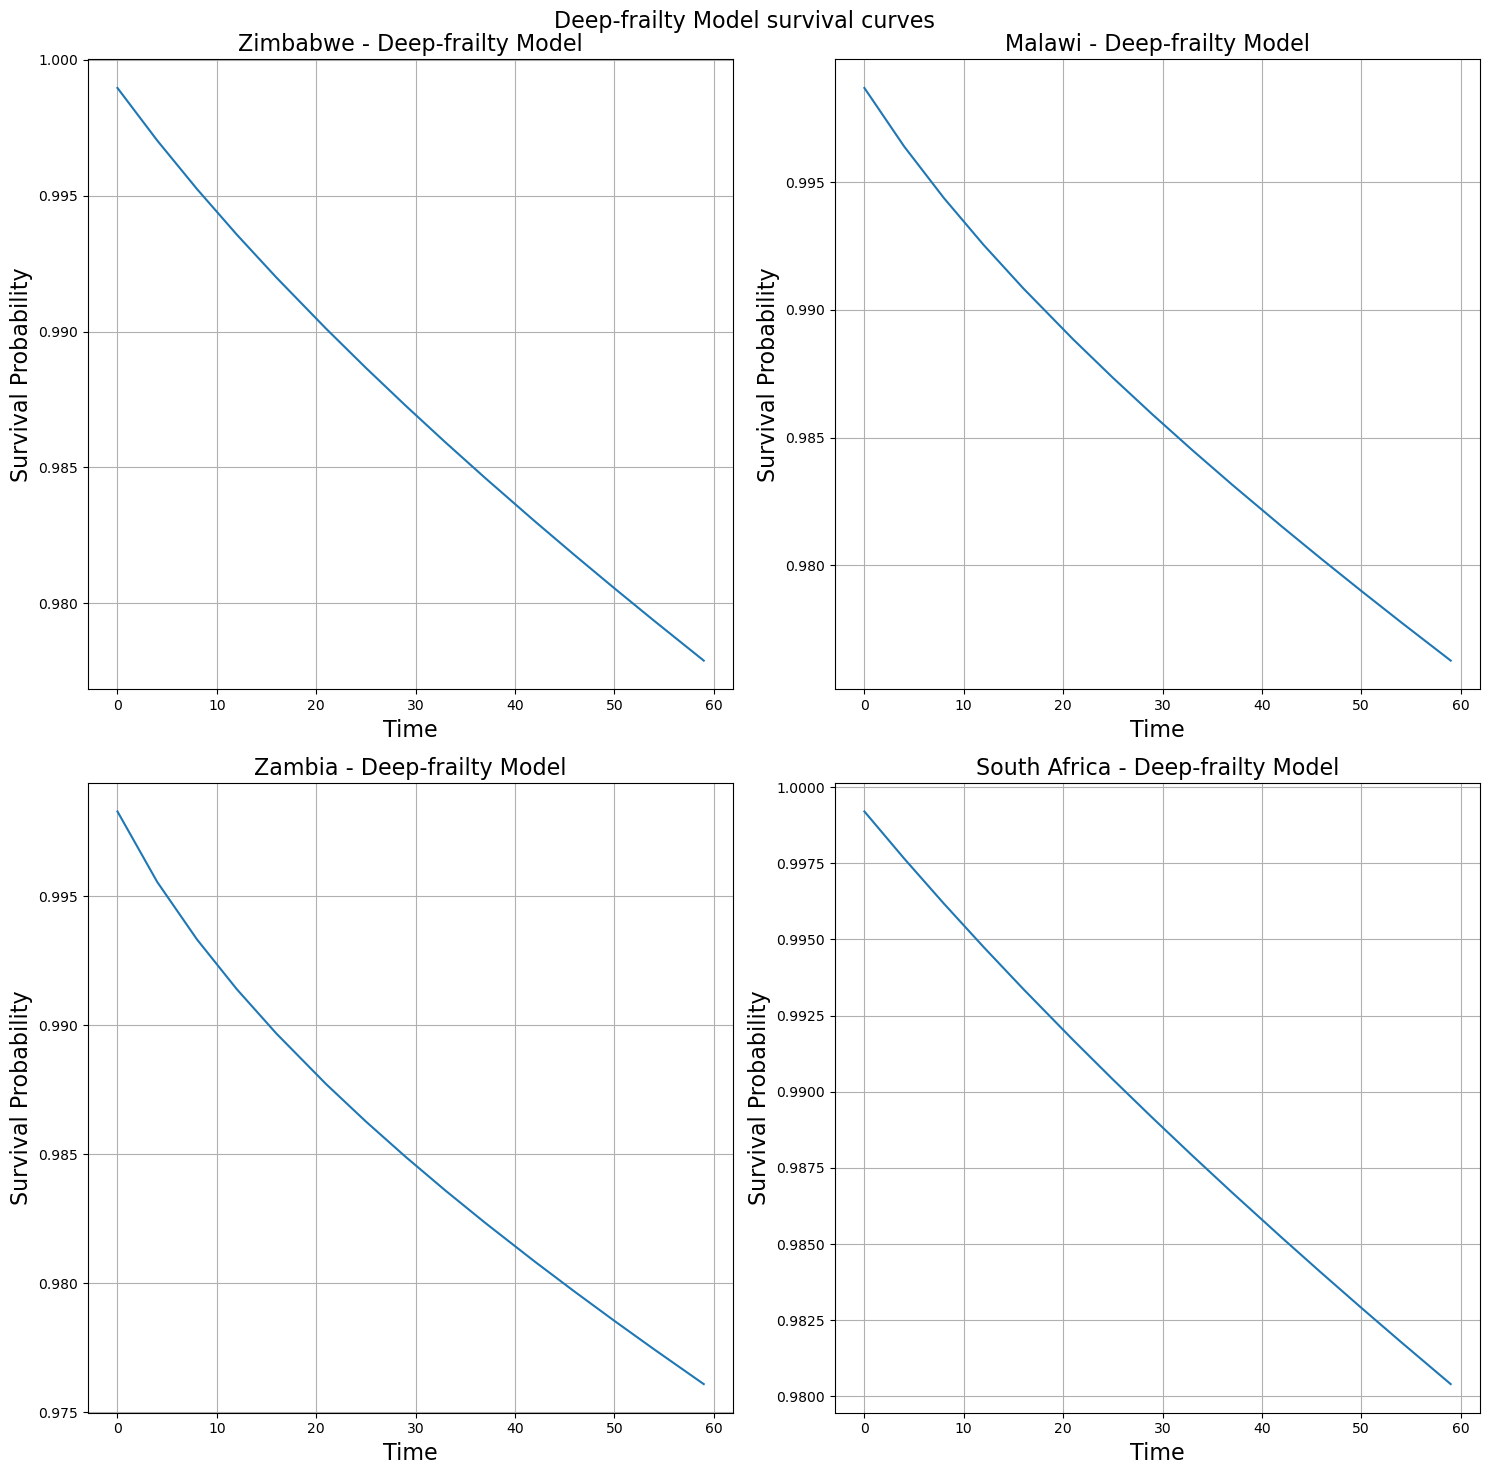

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the datasets (replace with your actual CSV files)
dfZim = pd.read_csv('Zimbabwe_resultssurvivalFULL.csv')
dfZamb = pd.read_csv('Zambia_resultssurvivalFULL.csv')
dfSouth = pd.read_csv('SouthAfrica_resultssurvivalFULL.csv')
dfMalawi = pd.read_csv('Malawi_resultssurvivalFULL.csv')

# Calculate the mean survival probability for each country
mean_Zim = dfZim.mean()
mean_Zamb = dfZamb.mean()
mean_South = dfSouth.mean()
mean_Malawi = dfMalawi.mean()

# Use linspace to generate fewer points for the x-axis (adjust based on time range)
time_points = np.linspace(0, 59, num=15, dtype=int)  # 15 evenly spaced points between 0 and 59

# Set default style to ensure a white background
plt.style.use('default')

# Create a figure with 4 subplots (2x2 grid), set facecolor to white
fig, axs = plt.subplots(2, 2, figsize=(15, 15), facecolor='white')

# Plot each country's mean survival curve in a separate subplot
# Zimbabwe
axs[0, 0].plot(time_points, mean_Zim[time_points].values, label='Fold 1')
axs[0, 0].set_title('Zimbabwe - Deep-frailty Model',fontsize=16)
axs[0, 0].set_xlabel('Time',fontsize=16)
axs[0, 0].set_ylabel('Survival Probability',fontsize=16)
axs[0, 0].grid(True)

# Malawi
axs[0, 1].plot(time_points, mean_Malawi[time_points].values, label='Fold 1')
axs[0, 1].set_title('Malawi - Deep-frailty Model',fontsize=16)
axs[0, 1].set_xlabel('Time',fontsize=16)
axs[0, 1].set_ylabel('Survival Probability',fontsize=16)
axs[0, 1].grid(True)

# Zambia
axs[1, 0].plot(time_points, mean_Zamb[time_points].values, label='Fold 1')
axs[1, 0].set_title('Zambia - Deep-frailty Model',fontsize=16)
axs[1, 0].set_xlabel('Time',fontsize=16)
axs[1, 0].set_ylabel('Survival Probability',fontsize=16)
axs[1, 0].grid(True)

# South Africa
axs[1, 1].plot(time_points, mean_South[time_points].values, label='Fold 1')
axs[1, 1].set_title('South Africa - Deep-frailty Model',fontsize=16)
axs[1, 1].set_xlabel('Time',fontsize=16)
axs[1, 1].set_ylabel('Survival Probability',fontsize=16)
axs[1, 1].grid(True)
fig.suptitle('Deep-frailty Model survival curves', fontsize=16)
# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [9]:
fig.suptitle('Deep-frailty Model survival curves', fontsize=16)
fig.tight_layout()

# SAVE THE FIGURE (important: use fig.savefig, and do it before show)
fig.savefig("deep_frailty_survival_curves.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [3]:
import os
print(os.getcwd())


/home/justine


In [99]:
import os
import pandas as pd
df_zimbabwe_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Zimbabwe_Cindex_BrierScoreRSF.csv'))
df_malawi_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Malawi_Cindex_BrierScoreRSF.csv'))
df_zambia_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Zambia_Cindex_BrierScoreRSF.csv'))
df_south_africa_rsf = pd.read_csv(os.path.join(os.getcwd(), 'South_Africa_Cindex_BrierScoreRSF.csv'))

df_zimbabwe_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Zimbabwe_Cindex_BrierScore_DeepHit.csv'))
df_malawi_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Malawi_Cindex_BrierScore_DeepHit.csv'))
df_zambia_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Zambia_Cindex_BrierScore_DeepHit.csv'))
df_south_africa_deephit = pd.read_csv(os.path.join(os.getcwd(), 'South_Africa_Cindex_BrierScore_DeepHit.csv'))

df_zimbabwe_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_c_indicesFULLdataZimbabwesresultsNEW2.csv'))
df_malawi_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_c_indicesFULLdataMalawisresultsNEW2.csv'))
df_zambia_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_c_indicesFULLdataZambiasresultsNEW2.csv'))
df_south_africa_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_c_indicesFULLdataSouthAfricasresultsNEW2.csv'))

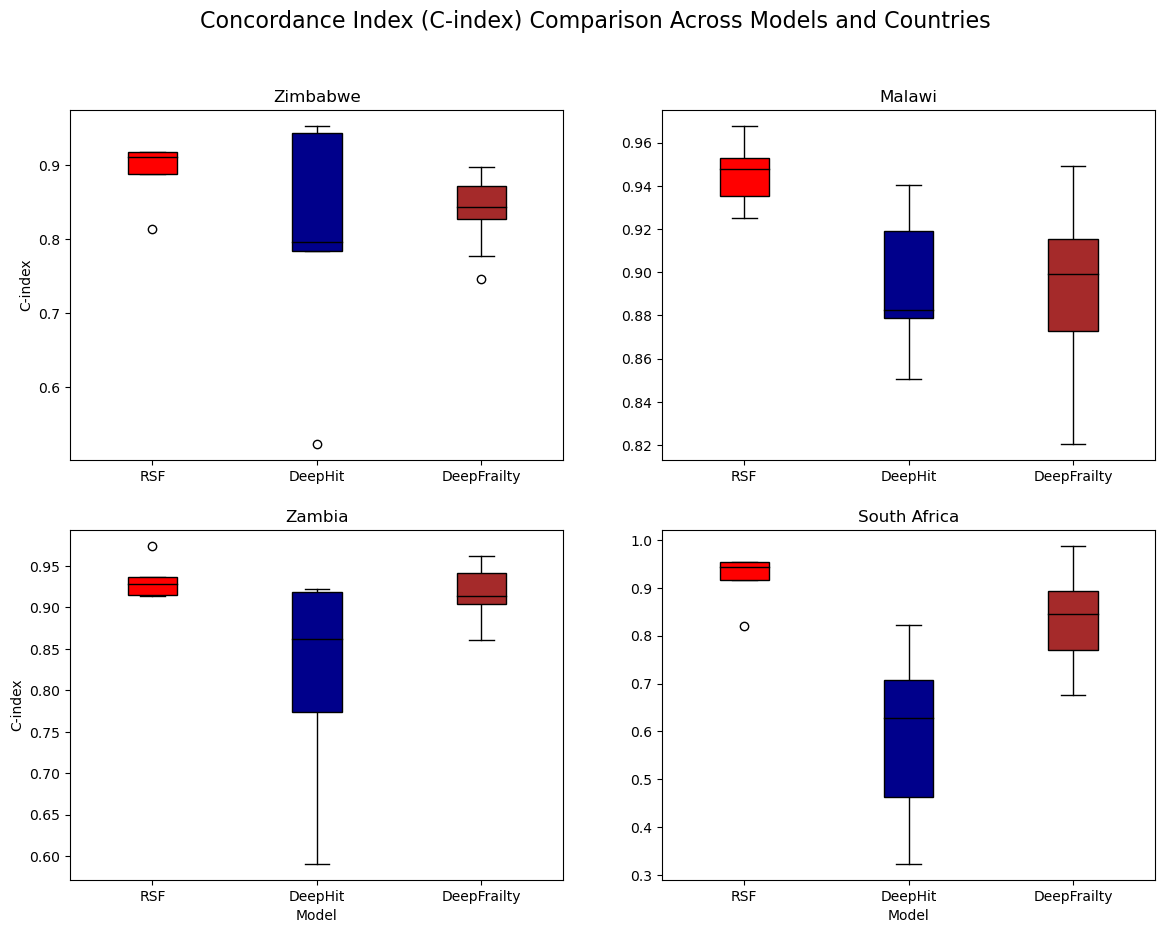

In [101]:
import matplotlib.pyplot as plt

# Prepare the C-index data for each country
data_zimbabwe = [
    df_zimbabwe_rsf['C-index'].tolist(), 
    df_zimbabwe_deephit['C-index'].tolist(), 
    df_zimbabwe_fraitly['fold_c_indices'].tolist()
]

data_malawi = [
    df_malawi_rsf['C-index'].tolist(), 
    df_malawi_deephit['C-index'].tolist(), 
    df_malawi_fraitly['fold_c_indices'].tolist()
]

data_zambia = [
    df_zambia_rsf['C-index'].tolist(), 
    df_zambia_deephit['C-index'].tolist(), 
    df_zambia_fraitly['fold_c_indices'].tolist()
]

data_south_africa = [
    df_south_africa_rsf['C-index'].tolist(), 
    df_south_africa_deephit['C-index'].tolist(), 
    df_south_africa_fraitly['fold_c_indices'].tolist()
]

# Colors for each model: red for RSF, dark blue for DeepHit, and brown for DeepFrailty
colors = ['red', 'darkblue', 'brown']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Common properties for the median line (set to black)
medianprops = dict(color='black')

# Plot for Zimbabwe
bplot1 = axes[0, 0].boxplot(data_zimbabwe, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('Zimbabwe')
axes[0, 0].set_ylabel('C-index')

# Plot for Malawi
bplot2 = axes[0, 1].boxplot(data_malawi, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot2['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 1].set_title('Malawi')

# Plot for Zambia
bplot3 = axes[1, 0].boxplot(data_zambia, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot3['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('Zambia')
axes[1, 0].set_ylabel('C-index')
axes[1, 0].set_xlabel('Model')

# Plot for South Africa
bplot4 = axes[1, 1].boxplot(data_south_africa, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot4['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 1].set_title('South Africa')
axes[1, 1].set_xlabel('Model')

# Adjust layout to avoid overlap
fig.suptitle('Concordance Index (C-index) Comparison Across Models and Countries', fontsize=16)
# Show the plot
plt.show()



In [105]:
import os
import pandas as pd
df_zimbabwe_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Zimbabwe_Cindex_BrierScoreRSF.csv'))
df_malawi_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Malawi_Cindex_BrierScoreRSF.csv'))
df_zambia_rsf = pd.read_csv(os.path.join(os.getcwd(), 'Zambia_Cindex_BrierScoreRSF.csv'))
df_south_africa_rsf = pd.read_csv(os.path.join(os.getcwd(), 'South_Africa_Cindex_BrierScoreRSF.csv'))

df_zimbabwe_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Zimbabwe_Cindex_BrierScore_DeepHit.csv'))
df_malawi_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Malawi_Cindex_BrierScore_DeepHit.csv'))
df_zambia_deephit = pd.read_csv(os.path.join(os.getcwd(), 'Zambia_Cindex_BrierScore_DeepHit.csv'))
df_south_africa_deephit = pd.read_csv(os.path.join(os.getcwd(), 'South_Africa_Cindex_BrierScore_DeepHit.csv'))

df_zimbabwe_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_ibsFULLdataZambiasresultsNEW.csv'))
df_malawi_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_ibsFULLdataZambiasresultsNEW.csv'))
df_zambia_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_ibsFULLdataZambiasresultsNEW.csv'))
df_south_africa_fraitly = pd.read_csv(os.path.join(os.getcwd(), 'fold_ibsFULLdataZambiasresultsNEW.csv'))

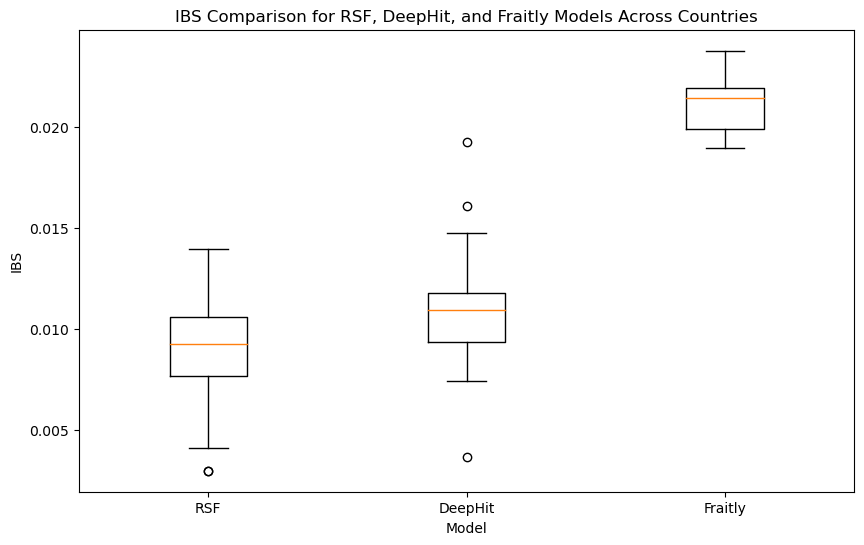

In [106]:
import matplotlib.pyplot as plt

# Define the column names for each dataset
column_name_rsf = 'Brier score'
column_name_deephit = 'Brier score at time 30.00'
column_name_fraitly = 'fold_ibs'

# Prepare the RSF data
data_rsf = (
    df_zimbabwe_rsf[column_name_rsf].tolist() +
    df_malawi_rsf[column_name_rsf].tolist() +
    df_zambia_rsf[column_name_rsf].tolist() +
    df_south_africa_rsf[column_name_rsf].tolist()
)

# Prepare the DeepHit data, handling the different column name for South Africa
data_deephit = (
    df_zimbabwe_deephit[column_name_deephit].tolist() +
    df_malawi_deephit[column_name_deephit].tolist() +
    df_zambia_deephit[column_name_deephit].tolist() +
    df_south_africa_deephit['Brier score at time 29.98'].tolist()
)

# Prepare the Fraitly data
data_fraitly = (
    df_zimbabwe_fraitly[column_name_fraitly].tolist() +
    df_malawi_fraitly[column_name_fraitly].tolist() +
    df_zambia_fraitly[column_name_fraitly].tolist() +
    df_south_africa_fraitly[column_name_fraitly].tolist()
)

# Create a figure and axis for the boxplot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the boxplot for each model's Brier score
ax.boxplot([data_rsf, data_deephit, data_fraitly], labels=['RSF', 'DeepHit', 'Fraitly'])

# Set the title and labels
ax.set_title('IBS Comparison for RSF, DeepHit, and Fraitly Models Across Countries')
ax.set_ylabel('IBS')
ax.set_xlabel('Model')

# Show the plot
plt.show()


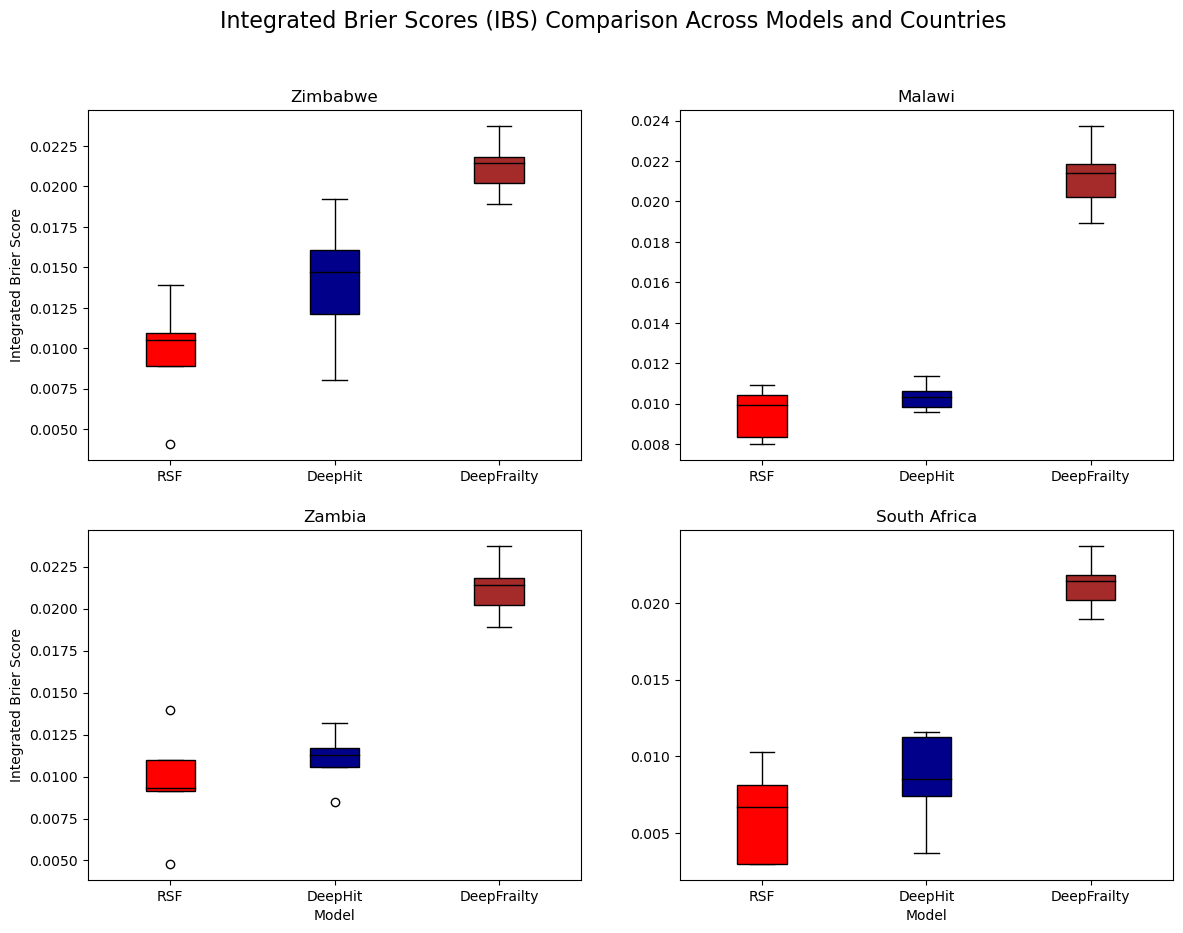

In [107]:
import matplotlib.pyplot as plt

# Define the column names for each dataset
column_name_rsf = 'Brier score'
column_name_deephit = 'Brier score at time 30.00'
column_name_fraitly = 'fold_ibs'

# Prepare the IBS data for each country
data_zimbabwe_ibs = [
    df_zimbabwe_rsf[column_name_rsf].tolist(), 
    df_zimbabwe_deephit[column_name_deephit].tolist(), 
    df_zimbabwe_fraitly[column_name_fraitly].tolist()
]

data_malawi_ibs = [
    df_malawi_rsf[column_name_rsf].tolist(), 
    df_malawi_deephit[column_name_deephit].tolist(), 
    df_malawi_fraitly[column_name_fraitly].tolist()
]

data_zambia_ibs = [
    df_zambia_rsf[column_name_rsf].tolist(), 
    df_zambia_deephit[column_name_deephit].tolist(), 
    df_zambia_fraitly[column_name_fraitly].tolist()
]

data_south_africa_ibs = [
    df_south_africa_rsf[column_name_rsf].tolist(), 
    df_south_africa_deephit['Brier score at time 29.98'].tolist(), 
    df_south_africa_fraitly[column_name_fraitly].tolist()
]

# Colors for each model: red for RSF, dark blue for DeepHit, and brown for DeepFrailty
colors = ['red', 'darkblue', 'brown']

# Create a 2x2 grid of subplots for each country
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Common properties for the median line (set to black)
medianprops = dict(color='black')

# Plot for Zimbabwe
bplot1 = axes[0, 0].boxplot(data_zimbabwe_ibs, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('Zimbabwe')
axes[0, 0].set_ylabel('Integrated Brier Score')

# Plot for Malawi
bplot2 = axes[0, 1].boxplot(data_malawi_ibs, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot2['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 1].set_title('Malawi')

# Plot for Zambia
bplot3 = axes[1, 0].boxplot(data_zambia_ibs, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot3['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('Zambia')
axes[1, 0].set_ylabel('Integrated Brier Score')
axes[1, 0].set_xlabel('Model')

# Plot for South Africa
bplot4 = axes[1, 1].boxplot(data_south_africa_ibs, labels=['RSF', 'DeepHit', 'DeepFrailty'], patch_artist=True, medianprops=medianprops)
for patch, color in zip(bplot4['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 1].set_title('South Africa')
axes[1, 1].set_xlabel('Model')

fig.suptitle('Integrated Brier Scores (IBS) Comparison Across Models and Countries', fontsize=16)

# Show the plot
plt.show()
